### Part 4: Time Series

### Statistics

### Central Tendency

### Mean

In [1]:
import numpy as np

trade_pnl = [10.0, 11.0, 9.0, -400.0, 2.0, 10.0, 11.9, 11.0, 8.0, 10.0, 10.2]
np.mean(trade_pnl)

np.float64(-27.900000000000002)

### Median

In [2]:
np.median(trade_pnl)

np.float64(10.0)

### Spread / Dispersion

### Standard Deviation

In [3]:
portfolio_a = [1.0, 1.0, -1.0, 1.0, 1.0 ,1.0,-1.0, 1.0, 1.0, 1.0]
np.sum(portfolio_a)

np.float64(6.0)

In [4]:
np.mean(portfolio_a)

np.float64(0.6)

In [5]:
np.std(portfolio_a)

np.float64(0.8000000000000002)

In [6]:
portfolio_b = [-10.0, 10.0, -10.0, 15.0, -10.0,16.0,-18.0, 13.0, -10.0, 10.0]
np.sum(portfolio_b)

np.float64(6.0)

In [7]:
np.std(portfolio_b)

np.float64(12.531560158256434)

### Risk-Adjusted Returns

In [8]:
import pandas as pd

pd.DataFrame({'portfolio_a':portfolio_a, 'portfolio_b':portfolio_b})

,portfolio_a,portfolio_b
0,1.0,-10.0
1,1.0,10.0
2,-1.0,-10.0
3,1.0,15.0
4,1.0,-10.0
5,1.0,16.0
6,-1.0,-18.0
7,1.0,13.0
8,1.0,-10.0
9,1.0,10.0


In [9]:
benchmark = pd.DataFrame([
    ['a', np.sum(portfolio_a), np.mean(portfolio_a), np.std(portfolio_a)],
    ['b', np.sum(portfolio_b), np.mean(portfolio_b), np.std(portfolio_b)]
], columns=['porfolio', 'total_pnl', 'mean_pnl', 'std_pnl'])

benchmark

,porfolio,total_pnl,mean_pnl,std_pnl
0,a,6.0,0.6,0.80000
1,b,6.0,0.6,12.53156


In [10]:
benchmark['sharpe'] = benchmark['mean_pnl'] / benchmark['std_pnl']
benchmark

,porfolio,total_pnl,mean_pnl,std_pnl,sharpe
0,a,6.0,0.6,0.80000,0.750000
1,b,6.0,0.6,12.53156,0.047879


### Correlation

### Positive Correlation

In [11]:
x = [1, 2, 3, 4]
y = [1, 3, 2, 5]

np.corrcoef(x,y)[0,1]


np.float64(0.8315218406202999)

In [12]:
x = [1, 2, 3, 4]
y = [2, 3, 4, 5]

np.corrcoef(x,y)[0,1]


np.float64(1.0)

### Negative Correlation

In [16]:
x = [1, 2, 3, 4]
y = [-1, -3, -2, -6]

np.corrcoef(x,y)[0,1]


np.float64(-0.8366600265340756)

In [17]:
x = [1, 2, 3, 4]
y = [-1, -2, -3, -4]

np.corrcoef(x, y)[0, 1]

np.float64(-1.0)

### Time Series

In [21]:
# Your shared link
url = 'https://drive.google.com/file/d/1qnX9GpiL5Ii1FEnHTIAzWnxNejWnilKp/view?usp=sharing'

# Convert to a direct download link
file_id = url.split('/d/')[1].split('/')[0]
direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'
direct_url

'https://drive.google.com/uc?export=download&id=1qnX9GpiL5Ii1FEnHTIAzWnxNejWnilKp'

In [23]:
import pandas as pd

btcusdt = pd.read_csv(
    "../data/BTCUSDT-1h.csv",
    parse_dates=["open_time"],
    index_col="open_time"
)

btcusdt

,open,high,low,close,volume
open_time,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299
...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325


<Axes: xlabel='open_time'>

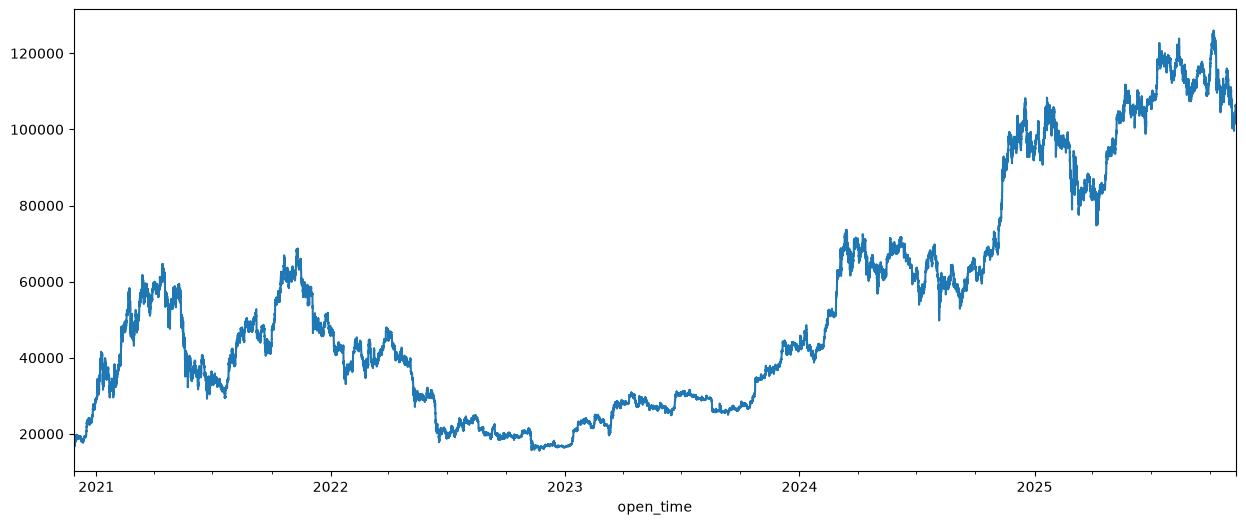

In [27]:
btcusdt['close'].plot(figsize=(15,6))

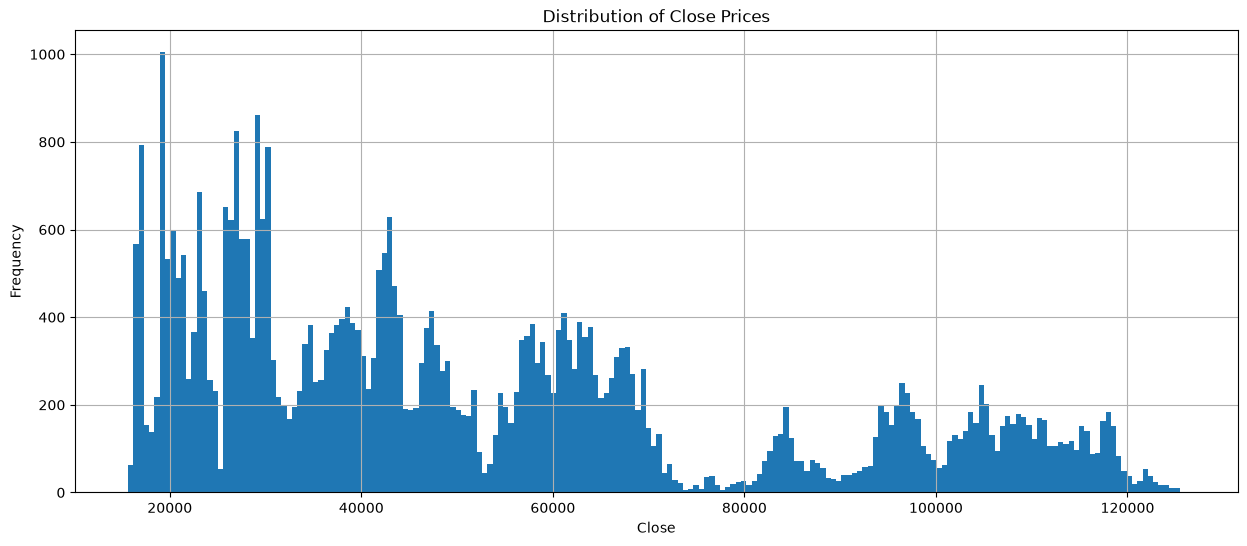

In [29]:
# Plot histogram of the 'close column
import matplotlib.pyplot as plt

btcusdt['close'].hist(bins=200, figsize=(15,6))
plt.title("Distribution of Close Prices")
plt.xlabel("Close")
plt.ylabel("Frequency")
plt.show()

In [30]:
btcusdt['close'].mean()

np.float64(52732.42998572744)

In [31]:
btcusdt['close'].std()

np.float64(29266.848389964485)

### Differencing

In [33]:
btcusdt['close_lag_1'] = btcusdt['close'].shift()
btcusdt['close_delta'] = btcusdt['close'] - btcusdt['close_lag_1']

btcusdt

,open,high,low,close,volume,close_delta,close_lag_1
open_time,,,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474,NaN,NaN
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689,-90.06,17400.00
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837,-207.56,17309.94
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593,-18.33,17102.38
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299,-4.49,17084.05
...,...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178,331.40,105435.80
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547,189.50,105767.20
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325,-373.20,105956.70


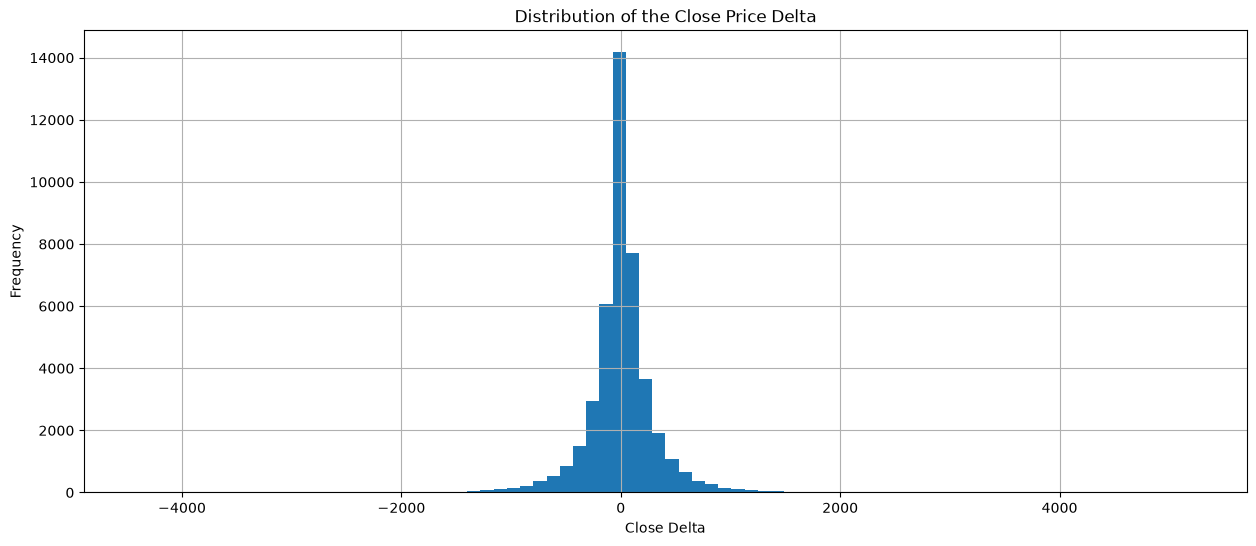

In [34]:
# Plot histogram of the "close_delta" column
btcusdt['close_delta'].hist(bins=80, figsize=(15,6))
plt.title("Distribution of the Close Price Delta")
plt.xlabel("Close Delta")
plt.ylabel("Frequency")
plt.show()

In [36]:
btcusdt['close_delta'].mean()


np.float64(2.038865995994383)

In [37]:
btcusdt['close_delta'].std()


np.float64(334.6994054851095)

### Stationary vs Non-Stationary

In [38]:
yearly_stats = btcusdt['close_delta'].resample('YE').agg(['mean', 'std'])

In [39]:
yearly_stats

,mean,std
open_time,,
2020-12-31,13.768391,172.361174
2021-12-31,1.970192,407.265282
2022-12-31,-3.387324,202.578210
2023-12-31,2.942511,131.701455
2024-12-31,5.832753,379.158165
2025-12-31,1.647744,462.794828


### Lags

In [ ]:
btcusdt['close_delta_lag_1'] = btcusdt['close_delta'].shift()
btcusdt['close_delta_lag_2'] = btcusdt['close_delta'].shift(2)
btcusdt['close_delta_lag_3'] = btcusdt['close_delta'].shift(3)
btcusdt['close_delta_lag_4'] = btcusdt['close_delta'].shift(4)


In [43]:
btcusdt[['close_delta', 'close_delta_lag_1', 'close_delta_lag_2','close_delta_lag_3','close_delta_lag_4']].head(10)

,close_delta,close_delta_lag_1,close_delta_lag_2,close_delta_lag_3,close_delta_lag_4
open_time,,,,,
2020-11-27 00:00:00,NaN,NaN,NaN,NaN,NaN
2020-11-27 01:00:00,-90.06,NaN,NaN,NaN,NaN
2020-11-27 02:00:00,-207.56,-90.06,NaN,NaN,NaN
2020-11-27 03:00:00,-18.33,-207.56,-90.06,NaN,NaN
2020-11-27 04:00:00,-4.49,-18.33,-207.56,-90.06,NaN
2020-11-27 05:00:00,187.98,-4.49,-18.33,-207.56,-90.06
2020-11-27 06:00:00,19.16,187.98,-4.49,-18.33,-207.56
2020-11-27 07:00:00,-181.45,19.16,187.98,-4.49,-18.33
2020-11-27 08:00:00,-247.50,-181.45,19.16,187.98,-4.49


In [44]:
btcusdt[['close_delta', 'close_delta_lag_1', 'close_delta_lag_2','close_delta_lag_3','close_delta_lag_4']].dropna().head(10)

,close_delta,close_delta_lag_1,close_delta_lag_2,close_delta_lag_3,close_delta_lag_4
open_time,,,,,
2020-11-27 05:00:00,187.98,-4.49,-18.33,-207.56,-90.06
2020-11-27 06:00:00,19.16,187.98,-4.49,-18.33,-207.56
2020-11-27 07:00:00,-181.45,19.16,187.98,-4.49,-18.33
2020-11-27 08:00:00,-247.50,-181.45,19.16,187.98,-4.49
2020-11-27 09:00:00,-196.77,-247.50,-181.45,19.16,187.98
2020-11-27 10:00:00,262.85,-196.77,-247.50,-181.45,19.16
2020-11-27 11:00:00,-126.64,262.85,-196.77,-247.50,-181.45
2020-11-27 12:00:00,273.80,-126.64,262.85,-196.77,-247.50
2020-11-27 13:00:00,-120.92,273.80,-126.64,262.85,-196.77


### Serial Correlation

In [45]:
btcusdt[['close_delta','close_delta_lag_1','close_delta_lag_2','close_delta_lag_3','close_delta_lag_4']].dropna().corr()

,close_delta,close_delta_lag_1,close_delta_lag_2,close_delta_lag_3,close_delta_lag_4
close_delta,1.000000,-0.010315,-0.007620,-0.004989,-0.004865
close_delta_lag_1,-0.010315,1.000000,-0.010312,-0.007622,-0.004987
close_delta_lag_2,-0.007620,-0.010312,1.000000,-0.010279,-0.007638
close_delta_lag_3,-0.004989,-0.007622,-0.010279,1.000000,-0.010261
close_delta_lag_4,-0.004865,-0.004987,-0.007638,-0.010261,1.000000


### Auto-Regression

### First-Order Auto-Regression Model: AR(1)

In [46]:
ts = pd.DataFrame({'log_return':[-0.1, 0.2, -0.2, 0.1, -0.3, 0.3]})

# Number of rows
n = len(ts)

# Create date index ending today
dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n, freq='D')

# Assign the date index
ts.index = dates

ts


,log_return
2026-07-11,-0.1
2026-07-12,0.2
2026-07-13,-0.2
2026-07-14,0.1
2026-07-15,-0.3
2026-07-16,0.3


In [50]:
ts['log_return_lag_1'] = ts['log_return'].shift()
ts

,log_return,log_return_lage_1,log_return_lag_1
2026-07-11,-0.1,NaN,NaN
2026-07-12,0.2,-0.1,-0.1
2026-07-13,-0.2,0.2,0.2
2026-07-14,0.1,-0.2,-0.2
2026-07-15,-0.3,0.1,0.1
2026-07-16,0.3,-0.3,-0.3


### AR(1) Model Definition

In [52]:
y = ts['log_return']
y_lag_1 = ts['log_return_lag_1']

weight = 0.0
bias = 0.0

y = weight * y_lag_1 + bias



### Fundamental Trading Dynamics

1. Mean Reversion
2. Momentum

### Mean Reversion

In [53]:
weight = -0.5
bias = 0.0001
ts['y_hat'] = weight * ts['log_return_lag_1'] + bias

ts

,log_return,log_return_lage_1,log_return_lag_1,y_hat
2026-07-11,-0.1,NaN,NaN,NaN
2026-07-12,0.2,-0.1,-0.1,0.0501
2026-07-13,-0.2,0.2,0.2,-0.0999
2026-07-14,0.1,-0.2,-0.2,0.1001
2026-07-15,-0.3,0.1,0.1,-0.0499
2026-07-16,0.3,-0.3,-0.3,0.1501


### Momentum

In [55]:
ts = pd.DataFrame({'log_return':[0.1,0.2,0.3,0.4,-0.1,-0.2,-0.3,-0.4]})

# Number of rows
n = len(ts)

# Create data index ending today
dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n, freq='D')

ts.index = dates
ts['log_return_lag_1'] = ts['log_return'].shift()
ts

,log_return,log_return_lag_1
2026-07-09,0.1,NaN
2026-07-10,0.2,0.1
2026-07-11,0.3,0.2
2026-07-12,0.4,0.3
2026-07-13,-0.1,0.4
2026-07-14,-0.2,-0.1
2026-07-15,-0.3,-0.2
2026-07-16,-0.4,-0.3


In [60]:
weight = 0.5
bias = 0.0001

ts['y_hat'] = weight * ts['log_return_lag_1'] + bias

ts

,log_return,log_return_lag_1,y_hat
2026-07-09,0.1,NaN,NaN
2026-07-10,0.2,0.1,0.0501
2026-07-11,0.3,0.2,0.1001
2026-07-12,0.4,0.3,0.1501
2026-07-13,-0.1,0.4,0.2001
2026-07-14,-0.2,-0.1,-0.0499
2026-07-15,-0.3,-0.2,-0.0999
2026-07-16,-0.4,-0.3,-0.1499
